# Quantum Kernel Classifier on `make_moons` Dataset

This notebook demonstrates a **quantum kernel classifier** using [PennyLane](https://pennylane.ai/) and the `make_moons` dataset.

A **quantum kernel** computes the similarity between data points by embedding them into quantum states and evaluating their inner product. This approach allows classical classifiers (like SVM) to operate in a **quantum-enhanced feature space**.

Steps:
1. Generate and visualize the dataset (`make_moons`).
2. Define a quantum feature map to encode classical data.
3. Compute the quantum kernel matrix for training and testing sets.
4. Train a classical SVM using the quantum kernel.
5. Evaluate classification performance.


In [1]:
import pennylane as qml
from pennylane import numpy as np
from pennylane import qchem
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

np.random.seed(0)


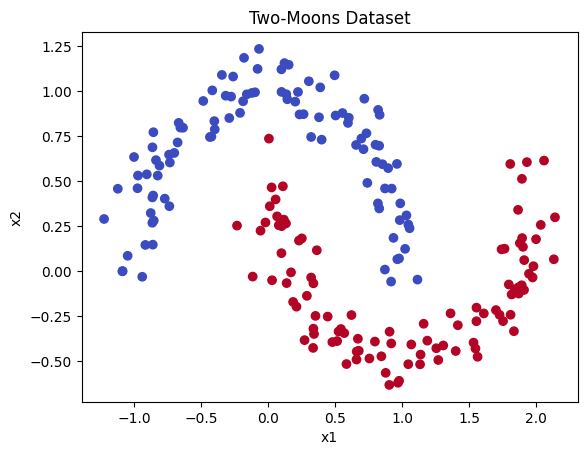

In [2]:
# Generate 2D "moons" dataset and split into train/test
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Visualize dataset
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
plt.title("Two-Moons Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


In [4]:
# Define a 2-qubit quantum device
dev = qml.device("default.qubit", wires=2)

def feature_map(x):
    """Encodes 2D input into quantum state for kernel evaluation."""
    qml.RX(x[0], wires=0)
    qml.RX(x[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RZ(x[0] * x[1], wires=0)


# QNode for kernel evaluation between two inputs
@qml.qnode(dev)
def kernel_circuit(x):
    feature_map(x)
    return qml.state()

# Compute kernel matrices
def compute_kernel_matrix(X1, X2):
    n1 = len(X1)
    n2 = len(X2)
    K = np.zeros((n1, n2))
    for i in range(n1):
        psi_i = kernel_circuit(X1[i])
        for j in range(n2):
            psi_j = kernel_circuit(X2[j])
            K[i,j] = np.abs(np.vdot(psi_i, psi_j))**2  # squared fidelity
    return K

K_train = compute_kernel_matrix(X_train, X_train)
K_test = compute_kernel_matrix(X_test, X_train)  # Note: train data as reference


In [5]:
# Train classical SVM using quantum kernel
svm = SVC(kernel='precomputed')
svm.fit(K_train, y_train)


,C,1.0
,kernel,'precomputed'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [6]:
y_pred = svm.predict(K_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")


Test Accuracy: 87.50%


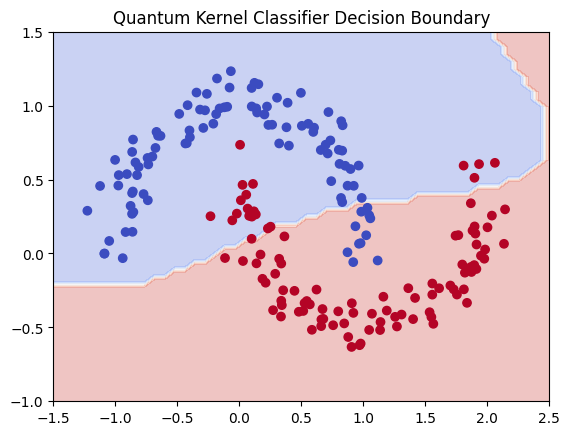

In [7]:
# Simple meshgrid visualization of decision boundary
xx, yy = np.meshgrid(np.linspace(-1.5,2.5,50), np.linspace(-1,1.5,50))
grid_points = np.c_[xx.ravel(), yy.ravel()]
K_grid = compute_kernel_matrix(grid_points, X_train)
Z = svm.predict(K_grid).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
plt.title("Quantum Kernel Classifier Decision Boundary")
plt.show()
